#  Car Price Prediction Using Machine Learning


**Project by:** Dipali Khandar

**Domain:** Data Science

##1. Introduction

Car price prediction is a Machine Learning application that estimates the selling price of a car based on features such as age, mileage, fuel type, transmission, and ownership history. In this project, a Random Forest Regression model is developed to analyze car data and predict prices accurately, demonstrating the complete machine learning workflow from data preprocessing to model evaluation.

##2. Objectives

- Analyze car-related data.
- Build a machine learning model to predict car prices.
- Evaluate model accuracy and performance.
- Identify key factors affecting car prices.
- Estimate the selling price of used cars.

##3. Tools and Technologies Used

- **Python** – Programming language used for data analysis and machine learning.
- **Google Colab** – Development environment for writing and executing code.
- **Pandas** – Data manipulation and preprocessing.
- **NumPy** – Numerical computations and array operations.
- **Matplotlib** – Data visualization and plotting.
- **Seaborn** – Statistical data visualization.
- **Scikit-learn** – Machine learning library used for model building and evaluation.
- **Random Forest Regressor** – Machine learning algorithm used for car price prediction.

##4. Importing Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##5. Loading Dataset

### Dataset Preview

* Let's examine the first few rows of the dataset.

In [8]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/car data.csv')

df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


##6. Dataset Overview

###Dataset Information

* Let's understand the structure of the dataset including columns, data types, and non-null values.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


### Statistical Summary

* Generate descriptive statistics to understand the distribution of numerical features.

In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


###Check Missing Values

* Before building the model, we verify whether the dataset contains any missing values.

In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [ ]:
df.shape

(301, 9)

* The dataset contains 301 rows and 9 columns.

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

##7. Exploratory Data Analysis
* Visualizing the distribution of selling prices.

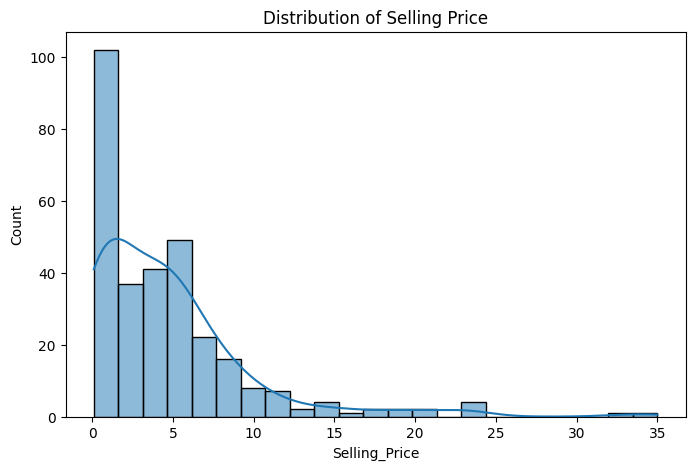

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')
plt.show()

### Observation

The distribution of selling prices shows that most cars have relatively lower selling prices, while a few cars are sold at significantly higher prices.

##8. Feature Engineering

Instead of using the manufacturing year directly, we create a new feature called **Car Age**.

Car Age is calculated as:

* Current Year - Manufacturing Year

This provides more meaningful information to the model.

In [9]:
from datetime import datetime
df['Car_Age'] = datetime.now().year - df['Year']

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


##9. Removing Unnecessary Columns

The columns **Car_Name** and **Year** are removed because:

- Car_Name contains too many unique values.
- Year has already been converted into Car_Age.

In [10]:
df.drop(['Car_Name','Year'], axis=1, inplace=True, errors='ignore')

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


## 10. Encoding Categorical Features

Machine Learning models cannot work directly with categorical data.

Therefore, we convert categorical variables into numerical format using One-Hot Encoding.

In [11]:
df = pd.get_dummies(
    df,
    columns=['Fuel_Type','Selling_type','Transmission'],
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


## 11. Correlation Heatmap

A correlation heatmap helps identify relationships between variables.

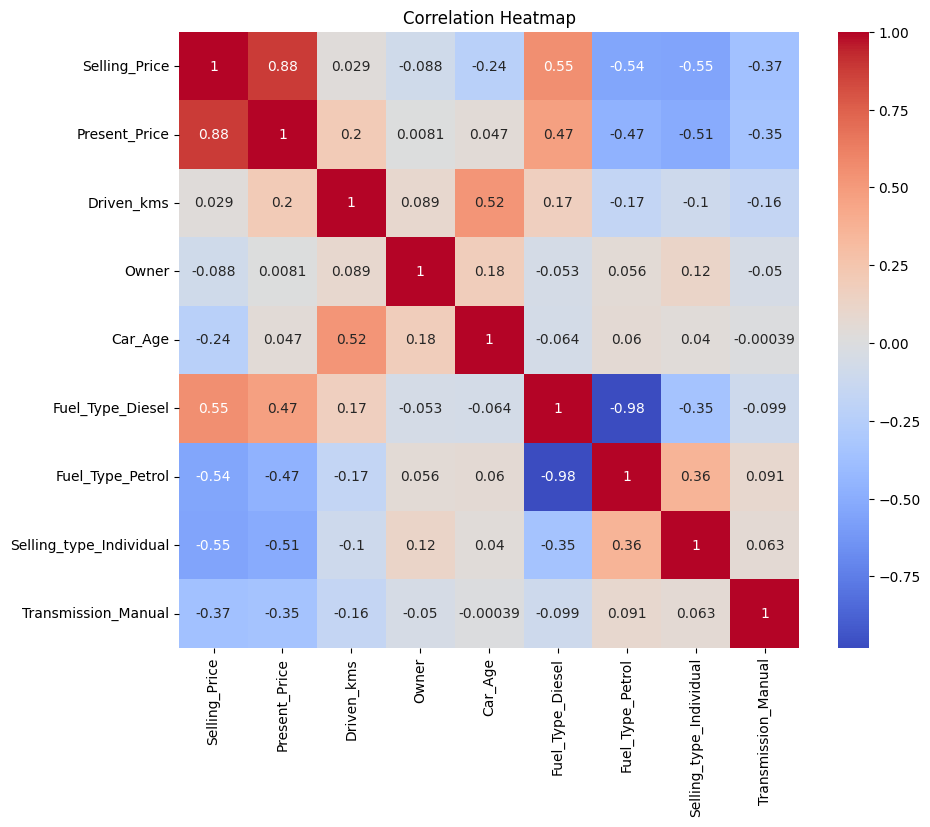

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 12. Define Features and Target Variable

Features (X) are used for prediction.

Target Variable (y) is the Selling Price.

In [12]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

## 13.  Split Dataset

The dataset is divided into:

- Training Data (80%)
- Testing Data (20%)

The training data is used to train the model, while testing data is used to evaluate performance.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (240, 8)
Testing Data: (61, 8)


### Observation

80% of the data is used for training and 20% for testing.

## 14. Model Training

We use the Random Forest Regressor algorithm because it performs well on regression tasks and can capture complex relationships in data.

In [14]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 15. Model Performance on Training and Testing Data

After training the model, we evaluate its performance on both the training and testing datasets. This helps determine whether the model is learning effectively and generalizing well to unseen data.

In [15]:
print("Training Score:", model.score(X_train, y_train))
print("Testing Score:", model.score(X_test, y_test))

Training Score: 0.9843033016205863
Testing Score: 0.9594566919773236


### Observation

A high training score and testing score indicate that the model is performing well. If the training score is much higher than the testing score, it may suggest overfitting.

## 16. Make Predictions

The trained model is used to predict car prices on unseen test data.

In [ ]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 0.4438, 10.9098,  4.9315,  0.2159,  7.7988,  6.2535,  1.1065,
        0.5876,  0.469 ,  6.896 ])

##17. Model Evaluation

The model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

A higher R² Score indicates better prediction performance.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 0.6368655737704919
Mean Squared Error: 0.9339387986885236
R² Score: 0.9594566919773236


### Interpretation

- Lower MAE indicates smaller prediction errors.
- Lower MSE indicates better model performance.
- R² Score closer to 1 indicates excellent prediction accuracy.

### Result

The Random Forest Regression model achieved strong predictive performance and was able to estimate car prices accurately based on the available features.

##18. Actual vs Predicted Prices

This visualization compares the actual selling prices with the predicted selling prices generated by the model.

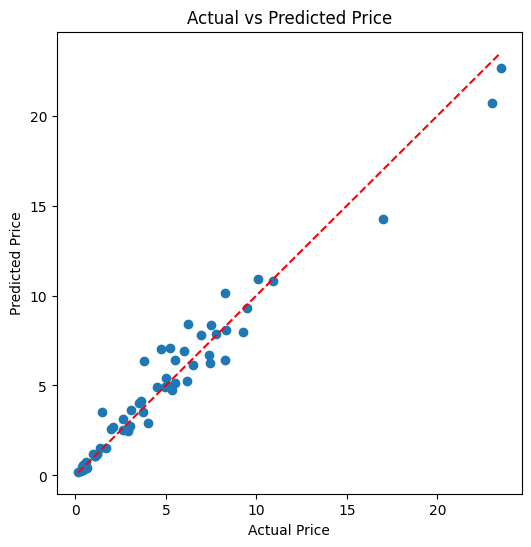

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

##19.  Feature Importance Analysis

Feature importance helps us understand which variables have the greatest impact on car price prediction.

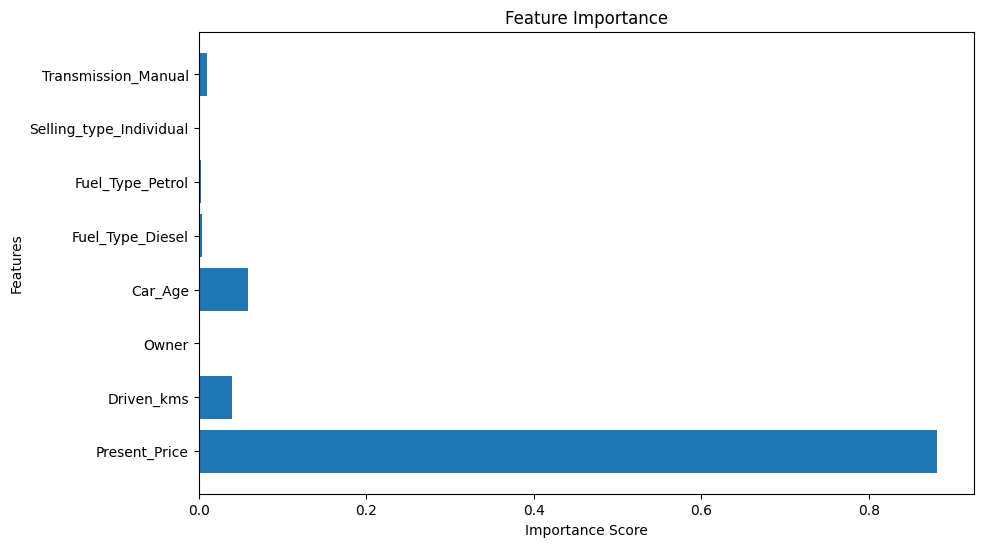

In [ ]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.title("Feature Importance")

plt.show()

##20. Predict Price of a New Car

The trained model can be used to estimate the selling price of a new car based on its characteristics.

In [ ]:
sample_car = X.iloc[0].values.reshape(1, -1)

prediction = model.predict(sample_car)

print("Predicted Selling Price:", prediction[0], "Lakhs")

Predicted Selling Price: 3.862500000000004 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 21. Key Findings

- The present price of a car has a significant impact on its selling price.
- Older cars generally have lower selling prices compared to newer cars.
- Cars with higher mileage (driven kilometers) tend to have lower resale values.
- Fuel type and transmission type also influence car prices.
- The Random Forest Regression model successfully captures the relationship between car features and selling price.
- Feature importance analysis helps identify the factors that contribute most to car price prediction.

##22.  Project Summary

This project uses Machine Learning to predict the selling price of used cars based on features such as car age, present price, kilometers driven, fuel type, and transmission type. A Random Forest Regression model was trained and evaluated to estimate car prices accurately, demonstrating the complete machine learning workflow from data preprocessing to prediction.

## 23. Conclusion

In this project, a Random Forest Regression model was developed to predict car selling prices.

The project successfully demonstrated:

- Data Preprocessing
- Feature Engineering
- Exploratory Data Analysis
- Model Training
- Model Evaluation
- Price Prediction

The model achieved strong predictive performance and can be used for real-world vehicle price estimation applications.